In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display, HTML
import plotly.graph_objects as go
import datetime


%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

In [2]:
agents = pd.read_csv("agentList_u2u9policy.csv", header=None, names=["person"], dtype={"person": "string"},usecols=[0])

persons_ctrl = pd.read_csv("berlin-v7.1-1pct.output_persons.csv", sep=";", low_memory=False)
persons_pol = pd.read_csv("berlin-v7.1-1pct-u2-u9-extension.output_persons.csv", sep=";", low_memory=False)

trips_ctrl = pd.read_csv("berlin-v7.1-1pct.output_trips.csv", sep=";", low_memory=False)
trips_pol = pd.read_csv("berlin-v7.1-1pct-u2-u9-extension.output_trips.csv", sep=";", low_memory=False)


In [3]:
all_agents = agents.drop_duplicates(subset=["person"])



persons_ctrl_filtered = persons_ctrl.merge(all_agents)
persons_pol_filtered = persons_pol.merge(all_agents)
trips_ctrl_filtered = trips_ctrl.merge(all_agents)
trips_pol_filtered = trips_pol.merge(all_agents)
#trips_ctrl_filtered = trips_ctrl_filtered[trips_ctrl_filtered["trip_number"] == 1]
#trips_pol_filtered = trips_pol_filtered[trips_pol_filtered["trip_number"] == 1]



In [4]:
total_trav_ctrl = pd.to_timedelta(trips_ctrl["trav_time"]).sum()
total_trav_pol = pd.to_timedelta(trips_pol["trav_time"]).sum()

ctrl_hours = total_trav_ctrl.total_seconds() / 3600
pol_hours = total_trav_pol.total_seconds() / 3600

print(f"Total travel time (control, all agents): {ctrl_hours:,.2f} h")
print(f"Total travel time (policy, all agents): {pol_hours:,.2f} h")
print(f"Difference: {pol_hours - ctrl_hours:,.2f} h")

ctrl_km = trips_ctrl["traveled_distance"].sum() / 1000
pol_km = trips_pol["traveled_distance"].sum() / 1000

print()
print(f"Total travel distance (control, all agents): {ctrl_km:,.2f} km")
print(f"Total travel distance (policy, all agents): {pol_km:,.2f} km")
print(f"Difference: {pol_km - ctrl_km:,.2f} km")

Total travel time (control, all agents): 82,646.10 h
Total travel time (policy, all agents): 82,577.02 h
Difference: -69.08 h

Total travel distance (control, all agents): 1,820,141.84 km
Total travel distance (policy, all agents): 1,821,197.24 km
Difference: 1,055.39 km


In [5]:
avg_per_agent_ctrl_km = trips_ctrl.groupby("person")["traveled_distance"].sum().mean() / 1000
avg_per_trip_ctrl_km = trips_ctrl["traveled_distance"].mean() / 1000

print(f"Base case, avg travel distance per agent: {avg_per_agent_ctrl_km:,.2f} km")
print(f"Base case, avg travel distance per trip:  {avg_per_trip_ctrl_km:,.2f} km")

Base case, avg travel distance per agent: 38.01 km
Base case, avg travel distance per trip:  9.94 km


In [15]:
ctrl_modes = trips_ctrl_filtered["main_mode"].value_counts()
pol_modes = trips_pol_filtered["main_mode"].value_counts()

modal_split = pd.DataFrame({
    "control_trips": ctrl_modes,
    "policy_trips": pol_modes,
}).fillna(0).astype(int)

modal_split["control_share_%"] = modal_split["control_trips"] / modal_split["control_trips"].sum() * 100
modal_split["policy_share_%"] = modal_split["policy_trips"] / modal_split["policy_trips"].sum() * 100
modal_split["abs_change_trips"] = modal_split["policy_trips"] - modal_split["control_trips"]
modal_split["share_change_pp"] = modal_split["policy_share_%"] - modal_split["control_share_%"]

print("Modal split (all agents, all trips):")
print(modal_split.round(2))

Modal split (all agents, all trips):
           control_trips  policy_trips  control_share_%  policy_share_%  \
main_mode                                                                 
bike                  85            75            19.23           16.97   
car                   75            74            16.97           16.74   
pt                   117           136            26.47           30.77   
ride                  23            19             5.20            4.30   
truck                  3             3             0.68            0.68   
walk                 139           135            31.45           30.54   

           abs_change_trips  share_change_pp  
main_mode                                     
bike                    -10            -2.26  
car                      -1            -0.23  
pt                       19             4.30  
ride                     -4            -0.90  
truck                     0             0.00  
walk                     -4      

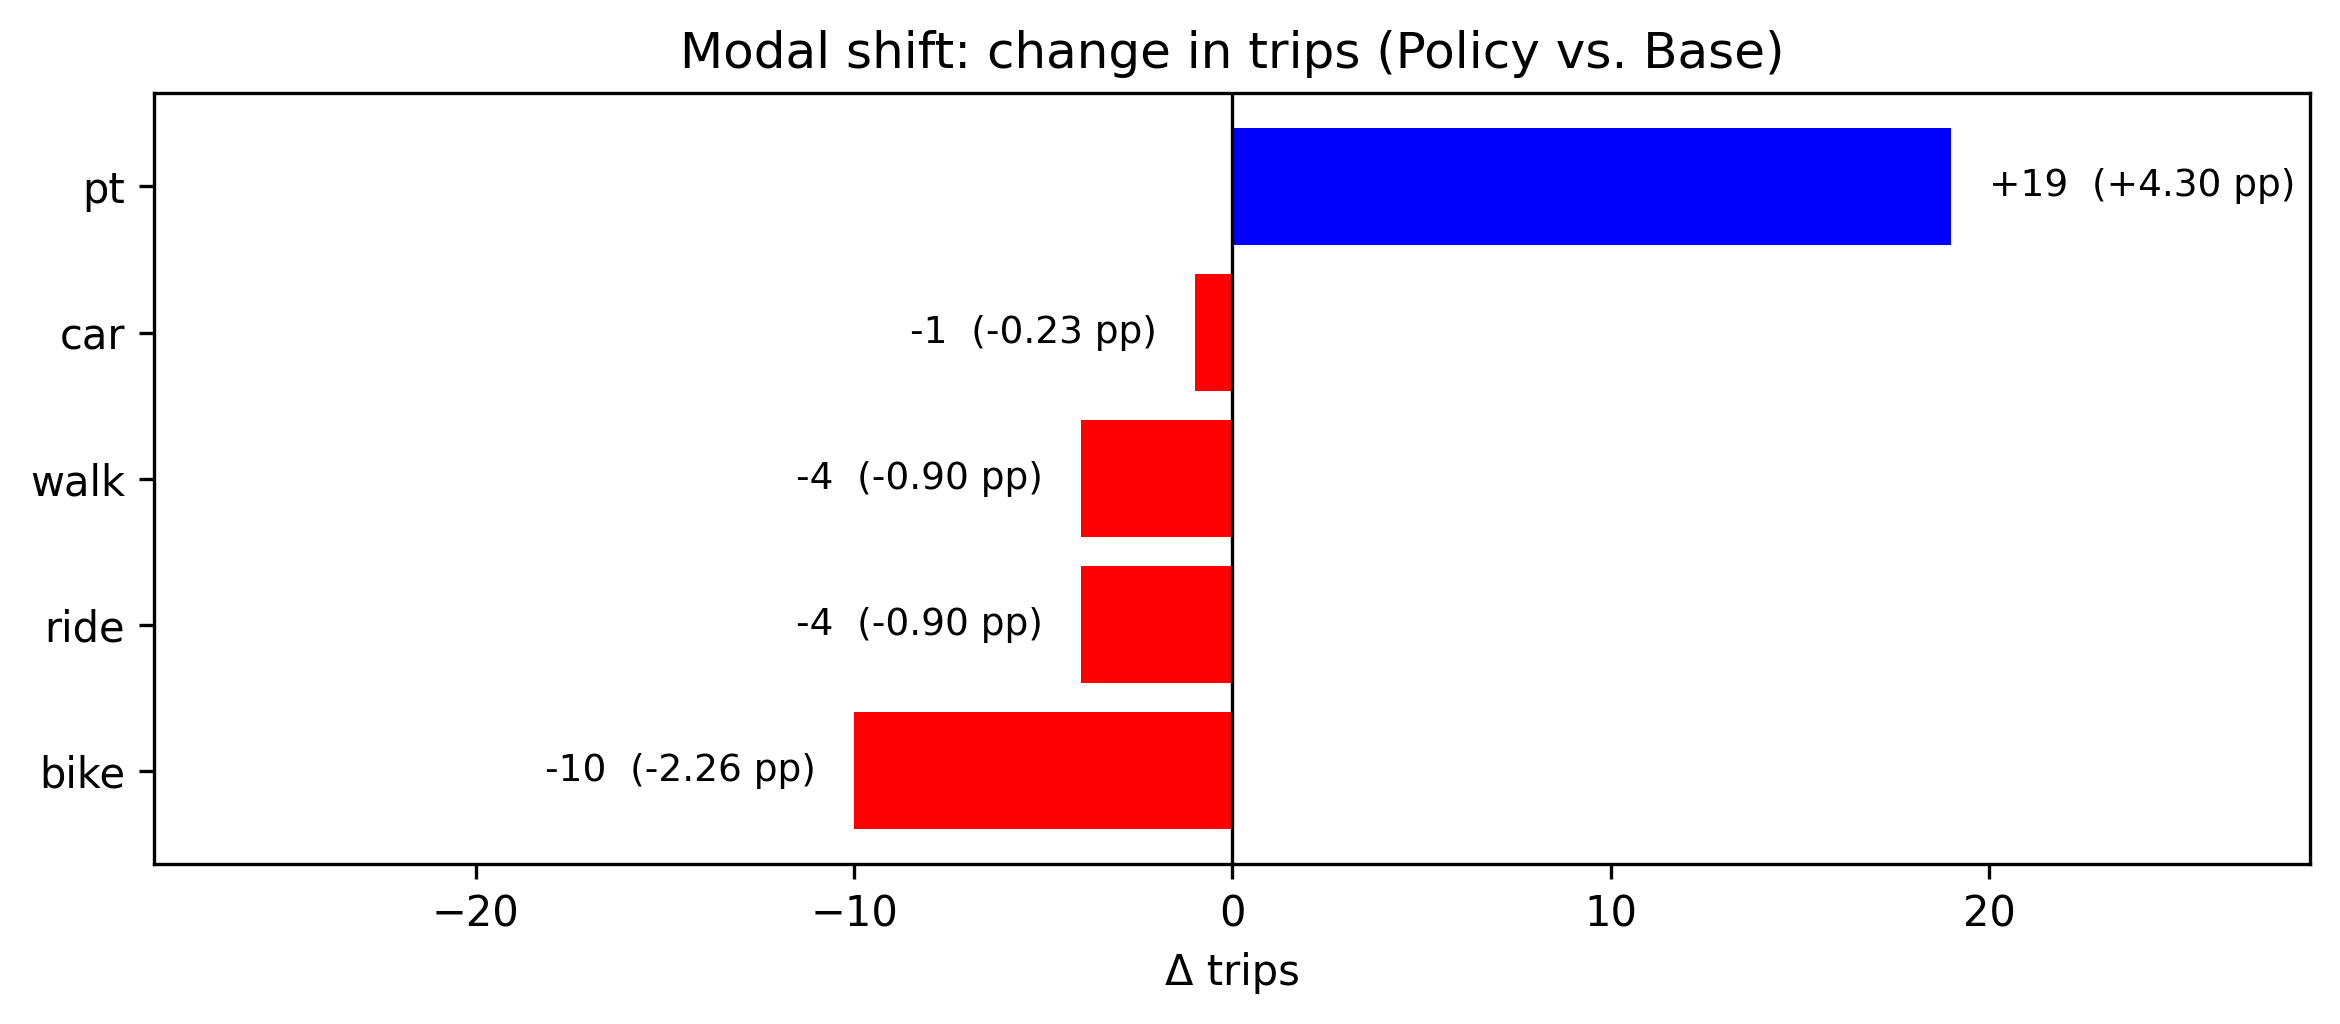

np.int64(439)

In [66]:
shift = modal_split.loc[~modal_split.index.str.startswith("truck")].copy()
shift = shift.sort_values("abs_change_trips")

colors = ["red" if v < 0 else "blue" for v in shift["abs_change_trips"]]

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(shift.index, shift["abs_change_trips"], color=colors)

ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Modal shift: change in trips (Policy vs. Base)")
ax.set_xlabel("Δ trips")

for bar, abs_v, pp in zip(bars, shift["abs_change_trips"], shift["share_change_pp"]):
    x = bar.get_width()
    offset = 1 if x >= 0 else -1
    ha = "left" if x >= 0 else "right"
    ax.text(x + offset, bar.get_y() + bar.get_height() / 2,
            f"{int(abs_v):+d}  ({pp:+.2f} pp)",
            va="center", ha=ha, fontsize=9)

xmax = max(abs(shift["abs_change_trips"].min()), abs(shift["abs_change_trips"].max()))
ax.set_xlim(-xmax * 1.5, xmax * 1.5)

plt.tight_layout()
plt.savefig("modal_shift_bars.png", bbox_inches="tight")
plt.show()
shift["control_trips"].sum()
shift["policy_trips"].sum()

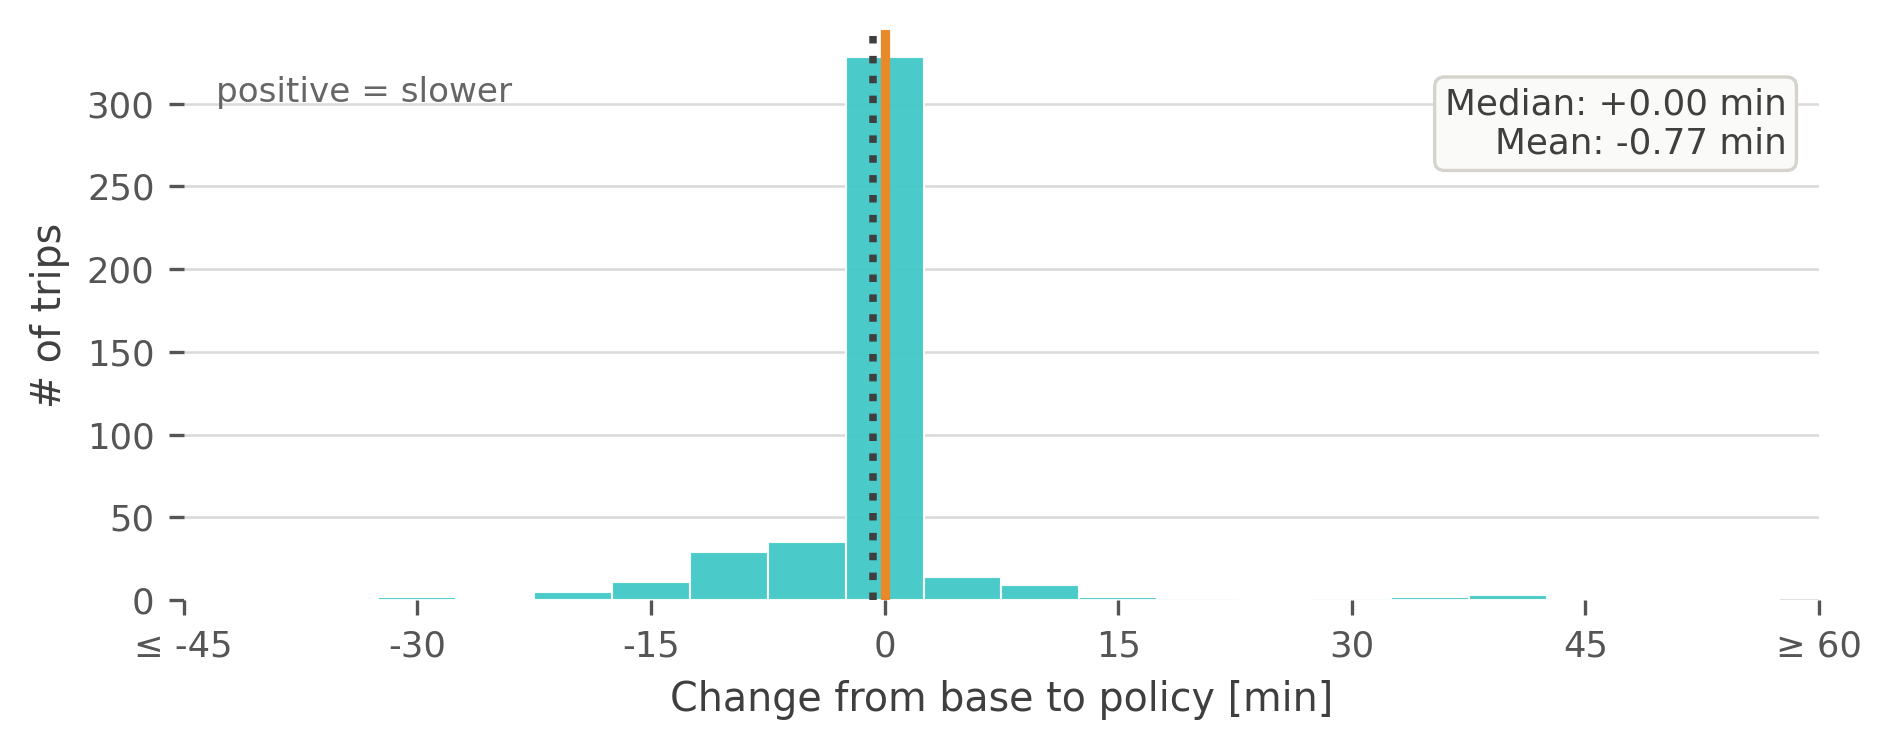

trav_time
 0.000000     272
-10.000000      3
-0.350000       3
-0.050000       3
-10.200000      2
             ... 
 34.450000      1
 37.200000      1
 39.900000      1
 42.133333      1
 42.316667      1
Name: count, Length: 159, dtype: int64

In [8]:
travel_time_dif = pd.to_timedelta(trips_pol_filtered["trav_time"]) - pd.to_timedelta(trips_ctrl_filtered["trav_time"])
travel_time_dif = travel_time_dif.dt.total_seconds() / 60


time_change = travel_time_dif.dropna()

turquoise = "#40C9C6"
orange = "#E98A2A"
dark = "#3F3F3F"
mid = "#666666"
grid = "#D9D9D9"
card_fill = "#FAFAF8"
card_border = "#D6D2CC"

x_min = -45
x_max = 60
bin_width = 5

left_outliers = (time_change < x_min).sum()
right_outliers = (time_change > x_max).sum()

time_change_display = time_change.clip(lower=x_min, upper=x_max)

bins = np.arange(x_min-2.5, x_max + bin_width-2.5, bin_width)

fig, ax = plt.subplots(figsize=(6.4, 2.6))

ax.hist(
    time_change_display,
    bins=bins,
    color=turquoise,
    edgecolor="white",
    linewidth=0.5,
    alpha=0.95
)

# Reference lines
ax.axvline(
    0,
    color=mid,
    linestyle="--",
    linewidth=1.2,
    alpha=0.9
)

ax.axvline(
    time_change.median(),
    color=orange,
    linewidth=2.2
)

ax.axvline(
    time_change.mean(),
    color=dark,
    linestyle=":",
    linewidth=1.8
)

ax.set_xlabel(
    "Change from base to policy [min]",
    fontsize=9.5,
    color=dark
)

ax.set_ylabel(
    "# of trips",
    fontsize=9.5,
    color=dark
)

ax.set_xlim(x_min, x_max)

xticks = [-45, -30, -15, 0, 15, 30, 45, 60]
xticklabels = ["≤ -45", "-30", "-15", "0", "15", "30", "45", "≥ 60"]

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)

ax.text(
    0.98,
    0.90,
    f"Median: {time_change.median():+.2f} min\nMean: {time_change.mean():+.2f} min",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=8.6,
    color=dark,
    bbox=dict(
        boxstyle="round,pad=0.28",
        facecolor=card_fill,
        edgecolor=card_border,
        linewidth=0.8
    )
)

ax.text(
    0.02,
    0.92,
    "positive = slower",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=8.2,
    color=mid
)

if left_outliers > 0 or right_outliers > 0:
    ax.text(
        0.5,
        -0.34,
        f"Edge bins include {left_outliers} trips ≤ {x_min} min and {right_outliers} trips ≥ {x_max} min.",
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=7.5,
        color=mid
    )

ax.grid(axis="y", color=grid, linewidth=0.6)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="both", labelsize=8.5, colors="#555555")

plt.tight_layout()

plt.savefig(
    "affected_agents_travel_time_hist_poster.svg",
    bbox_inches="tight"
)

plt.show()
time_change_display.sort_values().value_counts()


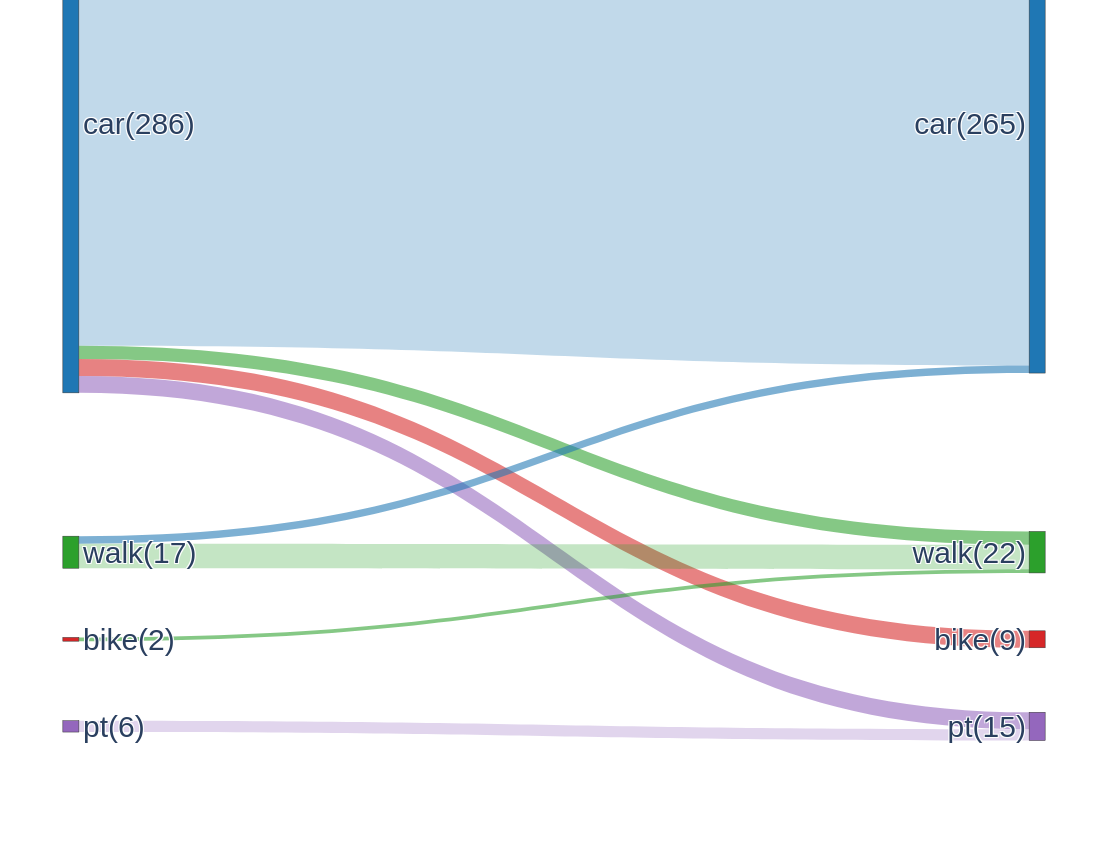

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


In [61]:
def_mode = "car"
car_persons = trips_ctrl_filtered.loc[
    trips_ctrl_filtered["main_mode"] == def_mode,
    ["person"]
].drop_duplicates()

trips_ctrl_car = trips_ctrl.merge(car_persons, on="person", how="inner")
trips_pol_car = trips_pol.merge(car_persons, on="person", how="inner")

ctrl_mode_car = trips_ctrl_car[["person", "trip_id", "main_mode"]].rename(
    columns={"main_mode": "before_mode"}
)

pol_mode_car = trips_pol_car[["person", "trip_id", "main_mode"]].rename(
    columns={"main_mode": "after_mode"}
)

merged_modes_car = pd.merge(
    ctrl_mode_car,
    pol_mode_car,
    on=["person", "trip_id"],
    how="inner"
)

mode_order = ["car", "ride", "walk", "bike", "pt"]

flows = (
    merged_modes_car
    .groupby(["before_mode", "after_mode"])
    .size()
    .reset_index(name="count")
)

flows = flows[
    flows["before_mode"].isin(mode_order)
    & flows["after_mode"].isin(mode_order)
].copy()

flows["before_mode"] = pd.Categorical(
    flows["before_mode"],
    categories=mode_order,
    ordered=True
)

flows["after_mode"] = pd.Categorical(
    flows["after_mode"],
    categories=mode_order,
    ordered=True
)

flows = flows.sort_values(["before_mode", "after_mode"])

total_flows = flows["count"].sum()

mode_colors = {
    "car": "#1f77b4",
    "ride": "#ff7f0e",
    "walk": "#2ca02c",
    "bike": "#d62728",
    "pt": "#9467bd"
}

def hex_to_rgba(hex_color, alpha):
    hex_color = hex_color.lstrip("#")
    r = int(hex_color[0:2], 16)
    g = int(hex_color[2:4], 16)
    b = int(hex_color[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"

before_nodes = [
    f"Before: {m}"
    for m in mode_order
    if m in flows["before_mode"].astype(str).unique()
]

after_nodes = [
    f"After: {m}"
    for m in mode_order
    if m in flows["after_mode"].astype(str).unique()
]

all_nodes = before_nodes + after_nodes
node_to_index = {node: idx for idx, node in enumerate(all_nodes)}

#node_labels = ["car", "ride", "walk", "bike", "pt"]

node_colors = [
    mode_colors[node.split(": ")[1]]
    for node in all_nodes
]

y_positions = {
    "car": 0.02,
    "ride": 0.53,
    "walk": 0.66,
    "bike": 0.79,
    "pt": 0.92,
}

node_x = []
node_y = []

for node in all_nodes:
    side, mode = node.split(": ")

    node_x.append(0.03 if side == "Before" else 0.97)
    node_y.append(y_positions[mode])

source = []
target = []
value = []
link_colors = []

for _, row in flows.iterrows():
    before_mode = str(row["before_mode"])
    after_mode = str(row["after_mode"])
    count = row["count"]

    source.append(node_to_index[f"Before: {before_mode}"])
    target.append(node_to_index[f"After: {after_mode}"])
    value.append(count)

    if before_mode == after_mode:
        alpha = 0.28
    else:
        alpha = 0.58

    link_colors.append(hex_to_rgba(mode_colors[after_mode], alpha))

node_labels = ["car(286)",  "walk(17)", "bike(2)", "pt(6)", "car(265)",  "walk(22)", "bike(9)", "pt(15)"]


fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="fixed",
            node=dict(
                pad=28,
                thickness=16,
                line=dict(color="#333333", width=0.5),
                label=node_labels*2,
                color=node_colors,
                x=node_x,
                y=node_y,
                
            ),
            link=dict(
                source=source,
                target=target,
                value=value,
                color=link_colors,
            ),
        )
    ]
)

fig.update_layout(
    width=1000,
    height=850,
    margin=dict(l=40, r=40, t=110, b=70),
    paper_bgcolor="white",
    plot_bgcolor="white",
     font_size=30,
)

fig.show()

fig.write_image("mode_shift_affected_"+ def_mode +"_sankey_no_labels.svg")
#(ctrl_mode_car["before_mode"] !="car").value_counts()
flows


after_mode  pt  bike  walk  ride
dist_band                       
0–2 km       0     3     6     0
2–5 km       3     1     1     0
5–10 km      4     5     0     0
10+ km       2     0     0     0


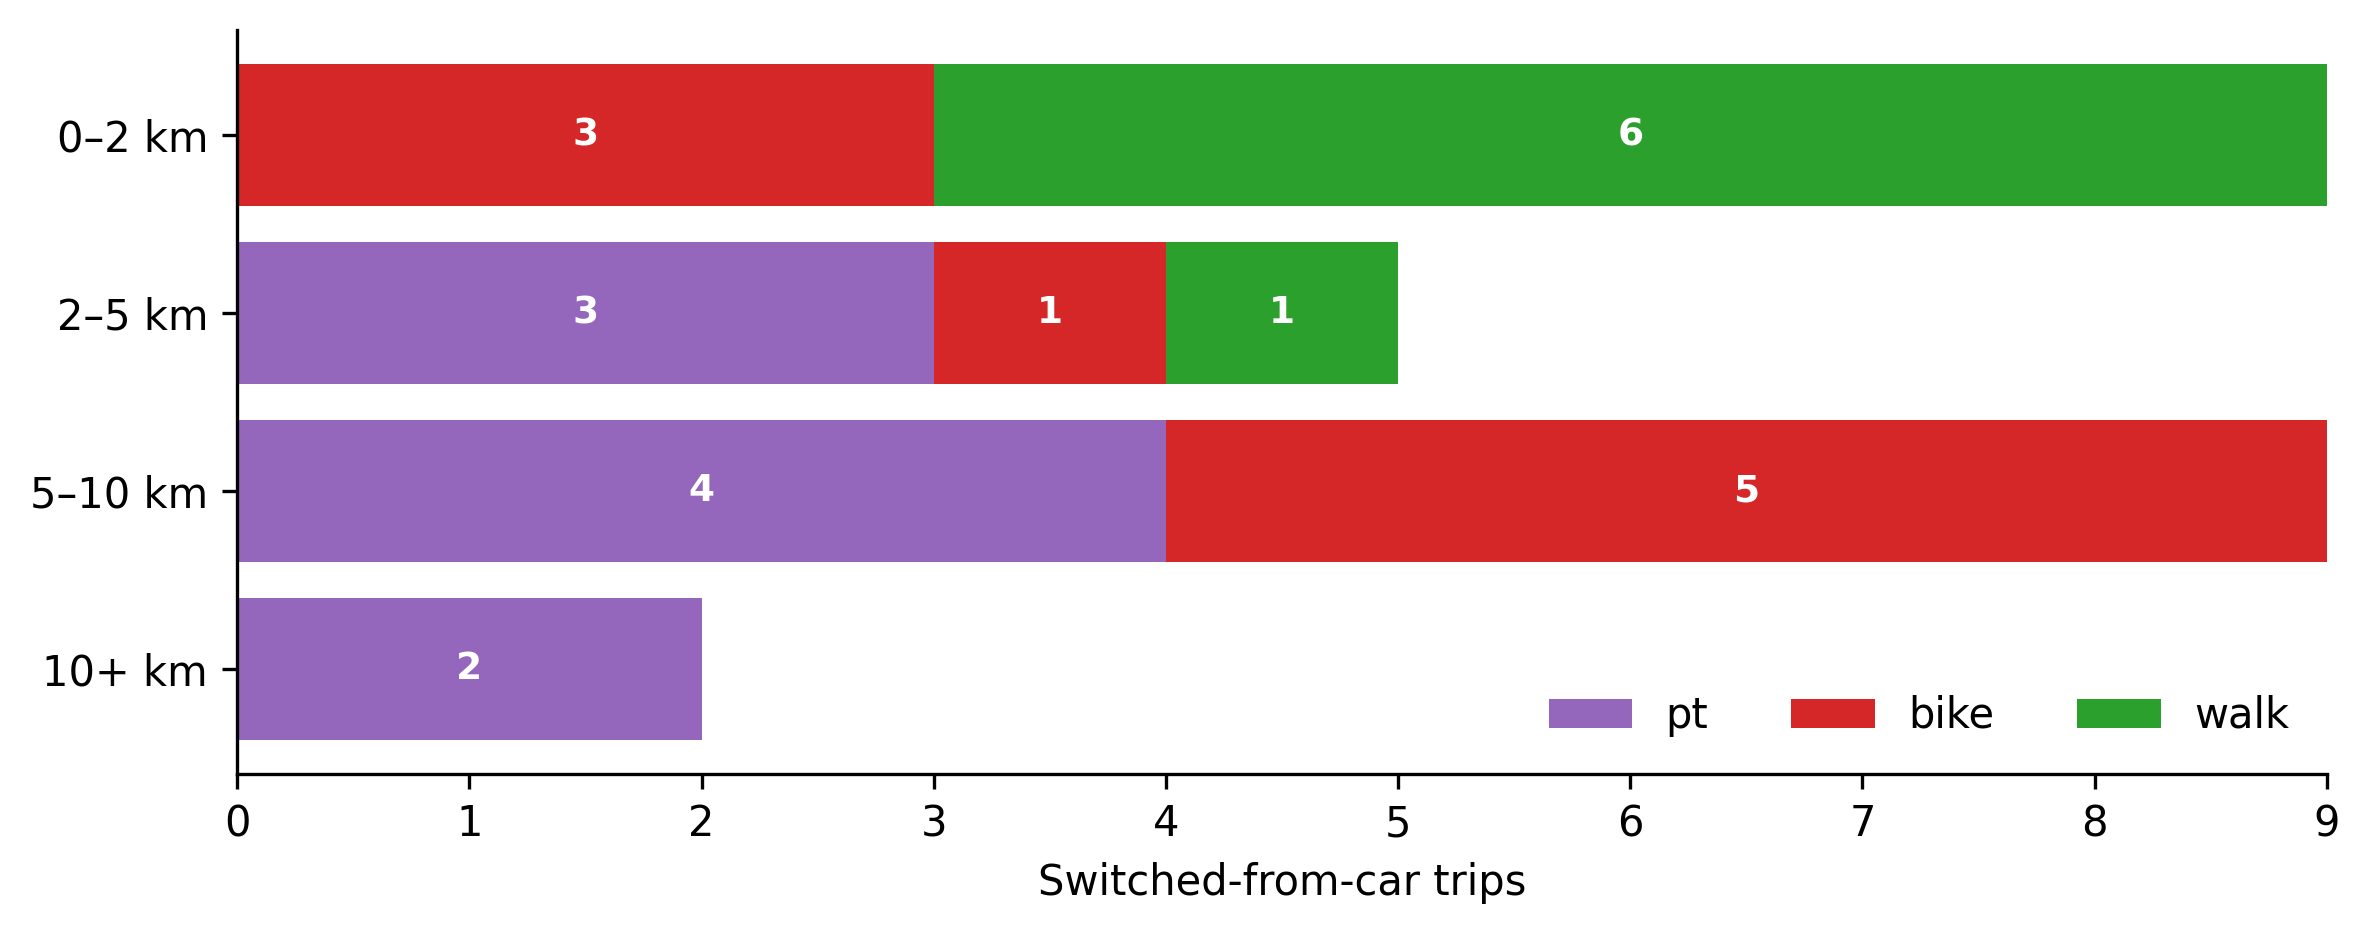

In [64]:
dist_ctrl = trips_ctrl_car[["person", "trip_id", "traveled_distance"]].rename(
    columns={"traveled_distance": "dist_m_base"}
)

merged_with_dist = merged_modes_car.merge(
    dist_ctrl, on=["person", "trip_id"], how="inner"
)
merged_with_dist["dist_km_base"] = merged_with_dist["dist_m_base"] / 1000

switched = merged_with_dist[
    (merged_with_dist["before_mode"] == "car")
    & (merged_with_dist["after_mode"] != "car")
    & (merged_with_dist["after_mode"].isin(["ride", "walk", "bike", "pt"]))
].copy()

bins   = [0, 2, 5, 10, np.inf]
labels = ["0–2 km", "2–5 km", "5–10 km", "10+ km"]
switched["dist_band"] = pd.cut(
    switched["dist_km_base"], bins=bins, labels=labels, right=False
)

pivot = (
    switched.groupby(["dist_band", "after_mode"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["pt", "bike", "walk", "ride"], fill_value=0)
    .reindex(index=labels, fill_value=0)
)

print(pivot)

mode_colors = {
    "pt":   "#9467bd",
    "bike": "#d62728",
    "walk": "#2ca02c",
    "ride": "#ff7f0e",
}

fig, ax = plt.subplots(figsize=(8, 3.2))

left = np.zeros(len(pivot))
for mode in ["pt", "bike", "walk"]:
    vals = pivot[mode].values
    ax.barh(pivot.index, vals, left=left, color=mode_colors[mode], label=mode)
    for i, v in enumerate(vals):
        if(int(v) != 0):
            ax.text(left[i] + v / 2, i, str(int(v)),
                        va="center", ha="center", color="white", fontsize=9, fontweight="bold")
    left += vals

ax.set_xlabel("Switched-from-car trips")
ax.invert_yaxis()  # short trips on top
ax.legend(loc="lower right", frameon=False, ncol=4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("mode_shift_by_distance.svg", bbox_inches="tight")
plt.show()